## Precipitation extremes networks for the southern peninsular region of India

    Wonjin Kim

### Research questions
1. Is it possible to use a threshold-based method to detect the EPEs?
2. Can we construct a precipitation network for the southern peninsular region of India during the monsoon season (JJAS)? What are typical network patterns?
3. In what ways do the patterns change under different ENSO phases?

### Hint
- Use the threshold approach to detect extreme values in each grid cell based on their first occurrence, ensuring that multiple peaks from the same rainfall event are not counted.
- Compute the network metrics separately for El Niño and La Niña years to understand how rainfall propagation pathways differ between these phases.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv

### Data

- Rainfall SP 1951 2023.csv contains rainfall data for the Indian peninsular region, where each row corresponds to one of 581 grid points in the southern peninsular area, and each column represents daily rainfall values (mm/day).
- Threshold MT AD.csv provides grid-wise threshold values (mm/day), with each row representing a grid point.
- Nino 3.4 index.csv contains the ENSO index data for the *Niño 3.4* region.

In [2]:
rain_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Rainfall_Daily_SP_1951_2023.csv")
threshold_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Threshold.csv")
enso_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Nina34_anom.csv")

In [3]:
print("rain_data shape :", rain_data.shape)
print("threshold_data shape :", threshold_data.shape)
print("enso_data shape :", enso_data.shape)

rain_data shape : (578, 26666)
threshold_data shape : (578, 4)
enso_data shape : (876, 2)


In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Deriving each variable from data
lats = np.array(rain_data['lat'])
lons = np.array(rain_data['lon'])


time_column_names = rain_data.columns[3:]
dates = pd.to_datetime(time_column_names)
jjas_mask = dates.month.isin([6, 7, 8, 9])
jjas_columns = time_column_names[jjas_mask]
rainfall = np.array(rain_data[jjas_columns]) #전체 행(전체 grid), 열은 3열에서부터 끝열까지 (mm/day)

thresholds_origin = np.array(threshold_data['Threshold'])

Text(0.5, 1.0, 'Spatial Distribution of Average Daily Rainfall (1951-2023)')

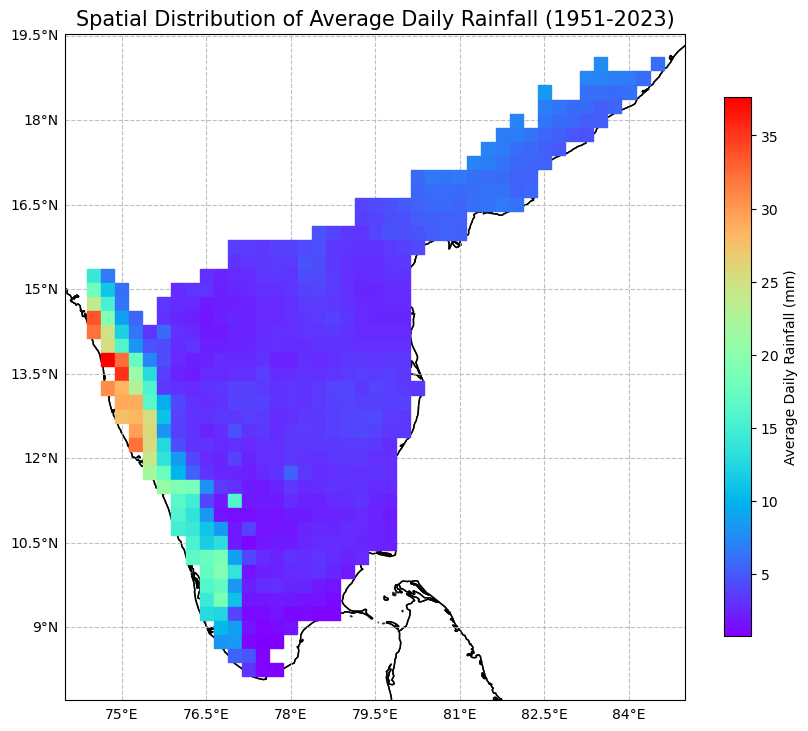

In [5]:
# Checking the average rainfall data
avg_rainfall = rainfall.mean(axis=1) # axis = 0 is column direction / axis = 1 is row direction

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1) # coastline
ax.add_feature(cfeature.BORDERS, linewidth=1) # landline
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='white') # land color
ax.add_feature(cfeature.OCEAN, edgecolor='black', facecolor='white', alpha = 0.6) # ocean color
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.8)
gl.top_labels = False
gl.right_labels = False

sc = ax.scatter(lons, lats, c=avg_rainfall, 
                cmap='rainbow', 
                s=90,          # spot size
                marker='s',    # spot shape (square)
                transform=ccrs.PlateCarree(),
                zorder=3)

cbar = plt.colorbar(sc, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Average Daily Rainfall (mm)')
plt.title('Spatial Distribution of Average Daily Rainfall (1951-2023)', fontsize=15)


## 1. Threshold method

### 1-1. Percentile Method

내가 임의로 추가한 것 :
강수량이 1mm 이상인 날에 한해서만 percentil을 해서 
90, 95% 상위 강수량 값을 threshold로 선택함.

90th Percentile: 21.90 mm
95th Percentile: 32.30 mm


Text(0, 0.5, 'numbers')

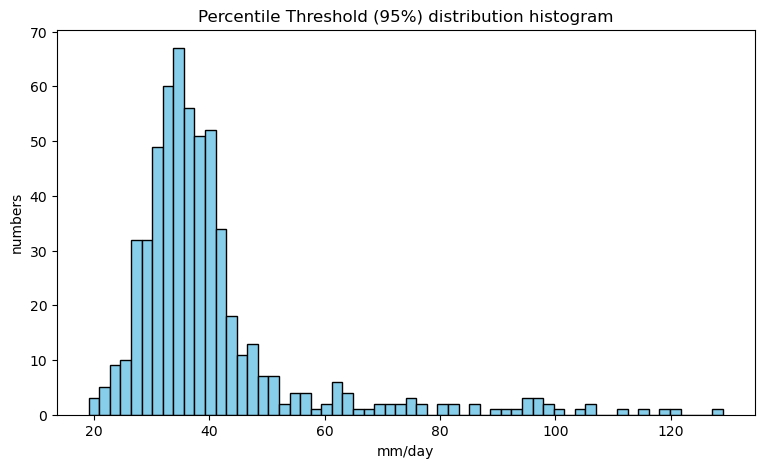

In [6]:
# Single threshold check
x = rainfall[0, :] # first local point's rainfall time series
wet_day = x[x >= 1.0] # define 'wet days' which has data larger than 1.0 mm/day
threshold_90 = np.percentile(x, 90)
threshold_95 = np.percentile(x, 95)

print(f"90th Percentile: {threshold_90:.2f} mm")
print(f"95th Percentile: {threshold_95:.2f} mm")

# Multiple threshold calculation

percentil_thresholds_95 = []
percentil_thresholds_90 = []

for i in range(rainfall.shape[0]):
    xx = rainfall[i, :]
    wet_days = xx[xx >= 1.0]
    th95 = np.percentile(wet_days, 95)
    th90 = np.percentile(wet_days, 90)
    percentil_thresholds_95.append(th95)
    percentil_thresholds_90.append(th90)


plt.figure(figsize=(9, 5))
plt.hist(percentil_thresholds_95, bins=60, color='skyblue', edgecolor='black')
plt.title("Percentile Threshold (95%) distribution histogram")
plt.xlabel("mm/day")
plt.ylabel("numbers")

### 1-2. Statistic Threshold Detection

#### AD method

1. The peaks are identified using a moving window approach for
a given time series {𝑥𝑖}. The peaks 𝑛𝑝 are the maximum values
at the center of a traversing window width of 7 to ensure their
independence. The peaks are sorted so that {𝑥1 ≤ ⋯ ≤ 𝑥𝑛𝑝}. (Anusha et al. 2025)

In [7]:
# Collecting peaks using window of size 7 (days)

def extract_independent_peaks(time_series, window_size = 7):
    peaks = []
    half_win = window_size // 2  # 7//2 = 3
    
    # 
    for i in range(half_win, len(time_series) - half_win):
        window = time_series[i - half_win : i + half_win + 1]
        center_val = time_series[i]
        
        # if center value is maximum and it has rain (> 0 mm/day) choose it as peak
        if center_val == np.max(window) and center_val > 0:
            peaks.append(center_val)
            
    return np.array(sorted(peaks)) # Ascending Sort

# sample test
sample_series = rainfall[0, :]
unique_peaks = extract_independent_peaks(sample_series)
print(f"number of extracted peaks: {len(unique_peaks)}")

# calculating peaks for all grids
obs_peaks = []
for i in range(len(rainfall)):
    obs_peaks.append(extract_independent_peaks(rainfall[i,:]))


number of extracted peaks: 1243


2. **Unique values** from $\{x_i; i = 1, \ldots, n_p\}$ are considered such that the series of thresholds are defined as $\{x_i; i = 1, \ldots, n_u\}$ and $n_u \leq n_p$. From this series, $\delta$ is calculated as

$$
\delta =
\frac{\max\{x_i; i = 1, \ldots, n_u\} - \min\{x_i; i = 1, \ldots, n_u\}}
{\text{length}\{x_i; i = 1, \ldots, n_u\}}
$$

- $n_p$ = number of peaks at each grid = $n_u$ = number of threshold candidate series at each grid
- delta = difference

In [8]:
delta = ( np.max(obs_peaks[0]) - np.min(obs_peaks[0]) ) / len(obs_peaks[0])

3. A new series of thresholds are computed using $\delta$, $\min\{x_i; i = 1, \ldots, n_u\}$ and $\max\{x_i; i = 1, \ldots, n_u\}$ such that the series become an equally spaced increasing threshold candidates $\{u_i, u_2, \ldots, u_{n_u}\}$.

In [9]:
u_candidates = []
for i in range(len(obs_peaks)):
    # Extract unique values
    unique_peaks = np.unique(obs_peaks[i])
    n_u = len(unique_peaks)
    
    # Exception
    if n_u < 2:
        u_candidates.append(np.array([]))
        continue

    min_val = np.min(unique_peaks)
    max_val = np.max(unique_peaks)

    u_candidates.append(
        np.linspace(min_val, max_val, n_u))

In [10]:
# array 'u' at each grid (this means grid 0's u array)
# this is independent and unique thresholds per grid.
u_candidates[0]

array([1.00000001e-01, 5.36439259e-01, 9.72878517e-01, 1.40931777e+00,
       1.84575703e+00, 2.28219629e+00, 2.71863555e+00, 3.15507481e+00,
       3.59151406e+00, 4.02795332e+00, 4.46439258e+00, 4.90083184e+00,
       5.33727109e+00, 5.77371035e+00, 6.21014961e+00, 6.64658887e+00,
       7.08302813e+00, 7.51946738e+00, 7.95590664e+00, 8.39234590e+00,
       8.82878516e+00, 9.26522441e+00, 9.70166367e+00, 1.01381029e+01,
       1.05745422e+01, 1.10109814e+01, 1.14474207e+01, 1.18838600e+01,
       1.23202992e+01, 1.27567385e+01, 1.31931777e+01, 1.36296170e+01,
       1.40660562e+01, 1.45024955e+01, 1.49389348e+01, 1.53753740e+01,
       1.58118133e+01, 1.62482525e+01, 1.66846918e+01, 1.71211311e+01,
       1.75575703e+01, 1.79940096e+01, 1.84304488e+01, 1.88668881e+01,
       1.93033273e+01, 1.97397666e+01, 2.01762059e+01, 2.06126451e+01,
       2.10490844e+01, 2.14855236e+01, 2.19219629e+01, 2.23584021e+01,
       2.27948414e+01, 2.32312807e+01, 2.36677199e+01, 2.41041592e+01,
      

#### Parameter calculation 


4. For each threshold $\{u_i, u_2, \ldots, u_{n_u}\}$, the GPD parameters are estimated using L-Moments for $x_i \geq u_j$. In addition, sampled peaks were compared to $1.65$ times the number of the years in the data series to ensure the peaks surpass this lower bound (Cunnane, 1973).

- Shape parameter : $$ \xi = \frac{\lambda_1 - u}{\lambda_2 - 2} $$
- Scale parameter : $$ \sigma = \frac{1 + \xi}{\lambda_1 - u} $$

by (12) equation, (Anusha et al. 2025)

In [11]:
# Define function that estimating GPD parameters based on L-Moment

def estimate_gpd_params_lmom(data, u):
    """
    data: peak value array that excess one threshold candidate (x >= u), x is peak values(observed real values) 
    u: a threshold candidate value that now on the test
    """
    n = len(data)
    if n < 2: return None, None
    
    sorted_data = np.sort(data)  # Ascending Sort
    
    # L-Moment : L-location (lambda1) & L-scale (lambda2)
    l1 = np.mean(sorted_data)  # lambda1: L-location, mean
    j = np.arange(n) # from j=0 to n-1 : (2*j - n + 1) * x_j / (n * (n-1))
    l2 = np.sum((2 * j - n + 1) * sorted_data) / (n * (n - 1)) # lambda2: L-scale, half the Mean absolute difference
    
    # Equation (12) plug in
    try:
        xi = ((l1 - u) / l2) - 2
        sigma = (l1 - u) * (1 + xi)
        return xi, sigma
    except ZeroDivisionError:
        return None, None

#### AD 

- $$ MAD = \frac{n}{2} - \sum_{i=1}^{n} \left[ \left( 2 - \frac{2i - 1}{n} \right) \log(1 - z_i) + 2z_i \right] \tag{15} $$
- For each unique potential threshold, $u_j$, $MAD(u_j)$ statistic and their corresponding $p$-value are estimated using the numerical approximation.
- The threshold $u_o$ which minimizes $(1 - p(u_j)) \forall u_j$ is considered as the optimal threshold for the time series $\{x_i; i = 1, \dots, n\}$.

In [12]:
# Define function that calculate AD(Anderson-Darling method)
from scipy.stats import genpareto

def calculate_mad_statistic(data, u, xi, sigma):
    n = len(data)
    sorted_data = np.sort(data)
    
    # theoritical CDF value : Equation (2) 
    z = genpareto.cdf(sorted_data, c = -xi, loc = u, scale = sigma)
    z = np.clip(z, 1e-10, 1 - 1e-10)
    
    # MAD Statistics calculation : Equation (15)
    i = np.arange(1, n + 1)
    term = (2 - (2 * i - 1) / n) * np.log(1 - z) + 2 * z
    mad = (n / 2) - np.sum(term)
    return mad

In [13]:
final_thresholds_AD = []

for i in range(len(u_candidates)): 
    grid_peaks = obs_peaks[i]
    candidates = u_candidates[i]
    
    best_u = None
    min_ad = float('inf')
    
    for u in candidates:
        # Extract peak values that is larger than selected u(a threshold candidate)
        excess_data = grid_peaks[grid_peaks >= u]
        
        # Limitate the number of samples by sampled peaks were compared to 1.65 times the number of the years
        if len(excess_data) < 1.65 * (2023 - 1951 + 1): 
            continue
            
        # Estimate parameters
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        if xi is None or sigma <= 0: continue
            
        # Calculating MAD
        ad_val = calculate_mad_statistic(excess_data, u, xi, sigma)
        
        # Finding specific 'u' that has minimal MAD value
        if ad_val < min_ad:
            min_ad = ad_val
            best_u = u
            
    final_thresholds_AD.append(best_u)

print(f"Best Threshold value at Grid 0: {final_thresholds_AD[0]} mm")

Best Threshold value at Grid 0: 36.76089765070723 mm


### Multiple Threshold Anderson–Darling Method (MT-AD)

For all $u_i$ which satisfy the condition 3 ($\zeta_u^c = \zeta_u^M$) in Section 2.4.4 are considered as the range of potential thresholds. The algorithm is explained below:

1. Evaluate the $MAD(u_i)$ statistic using Eq. (15) and the corresponding $p_i$ values.
2. Determine the smallest $1 - p_i$ value across all thresholds $u_i$, and select the $u_j$ corresponding to the minimum $MAD(u_j)$ statistic as the optimal threshold.

#### condition 3

1. The median of shape parameter $\xi$ is estimated as $\xi^M$ from the range of thresholds. The new scale parameter $\sigma_{u_i}'$ conditioned to $\xi^M \forall \{u_1, \dots, u_{n_u}\}$ is re-parameterized to
   $$\sigma_{u_i}^c = \sigma_{u_i} - \xi^M u_i \tag{19}$$
   along with the median of the scale parameter $\sigma_{u_i}^c$ as $\sigma_u^M$. The $\sigma_{u_i}^c$ parameter is invariant to increasing threshold as compared to $\sigma_{u_i}$.

2. In addition, the probability $\zeta_u$ of exceedances of threshold $u$ equal to $N_u/N$ is calculated, where $N_u$ denote the number of exceeding samples and $N$ as the total sample size. The new probability of exceedance $\zeta_u'$ conditioned to $\xi^M$ and $\sigma_u^M$ is re-parameterized to
   $$ \zeta_u^c = 
   \begin{cases} 
   \zeta_u (1 - \xi^M \frac{u}{\sigma_u^M})^{-1/\xi^M}, & \text{if } \xi^M \neq 0 \\
   \zeta_u \exp \frac{u}{\sigma_u^M}, & \text{if } \xi^M = 0 
   \end{cases} \tag{20} $$
   The median estimate $\zeta_u^M$ of the $\zeta_u^c$ denote the number of records above the optimal threshold and $\zeta_u^M$ is threshold invariant as compared to $\zeta_u$ which decreases with increasing threshold values.

3. The $u$ for which $\zeta_u^c = \zeta_u^M$ is regarded as the potential threshold.

In [14]:
# Calculating new threshold candidates which meet the condition 3

min_samples = int(1.65 * (2023 - 1951 + 1))

potential_thresholds_all = []
sigma_m_all = []
xi_median_all = []

for i in range(len(u_candidates)): 
    grid_peaks = obs_peaks[i] # multiple grids
    candidates = u_candidates[i]

    # at one grid. If out of one grid, those should be reset.
    xi_all_grid = []
    sigma_all_grid = []
    u_all_grid = []
    zeta_u_grid = []
    N = len(grid_peaks)
     
    # ---------------------------------------------------------
    # Starting inside one grid
    # ---------------------------------------------------------
    for u in candidates: # at fixed one grid
      excess_data = grid_peaks[grid_peaks >= u]
      N_u = len(excess_data) # number of excess data = N_u for equation (20)
      xi, sigma = estimate_gpd_params_lmom(excess_data, u)
      
      # sampled peaks limitation
      if N_u < min_samples:
          continue
      
      if xi is not None and sigma is not None:
         xi_all_grid.append(xi)
         sigma_all_grid.append(sigma)
         u_all_grid.append(u) # now you have filter(xi,sigma is not None), u is not the same with candidates anymore.
         zeta_u_grid.append(N_u / N)
    
    if len(xi_all_grid) == 0:
        potential_thresholds_all.append(np.array([]))
        continue

    # transtion to numpy array
    u_arr = np.array(u_all_grid)
    xi_arr = np.array(xi_all_grid)
    sigma_arr = np.array(sigma_all_grid) 
    zeta_u_arr = np.array(zeta_u_grid)

    # ---------------------------------------------------------
    # Step 1 : xi_median & sigma_m (Equation 19)
    # ---------------------------------------------------------
    xi_median = np.median(xi_arr)
    xi_median_all.append(xi_median)
    sigma_c_arr = sigma_arr - (xi_median * u_arr)
    sigma_m = np.median(sigma_c_arr)
    sigma_m_all.append(sigma_m)

    # ---------------------------------------------------------
    # Step 2 : zeta_u^c (Equation 20)
    # ---------------------------------------------------------
    if np.abs(xi_median) > 1e-6: # xi_median =/= 0 
      base = 1 - xi_median * (u_arr / sigma_m)
      base = np.maximum(base, 1e-10) 
      zeta_c_arr = zeta_u_arr * (base ** (-1 / xi_median))

    else: # xi_median == 0
      zeta_c_arr = zeta_u_arr * np.exp(u_arr / sigma_m)
    
    zeta_m = np.median(zeta_c_arr)
    # ---------------------------------------------------------
    # Step 3 : finding u met with Condition 3 (zeta_c == zeta_m)
    # ---------------------------------------------------------
    zeta_c_rounded = np.round(zeta_c_arr, 2)
    zeta_m_rounded = np.round(zeta_m, 2)
    valid_indices = np.where(zeta_c_rounded == zeta_m_rounded)[0]

    potential_u = u_arr[valid_indices]
    potential_thresholds_all.append(potential_u)

/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_58096/2751764097.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  xi = ((l1 - u) / l2) - 2
/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_58096/2751764097.py:20: RuntimeWarning: invalid value encountered in scalar divide
  xi = ((l1 - u) / l2) - 2


In [15]:
final_thresholds_MTAD = []

for i in range(len(potential_thresholds_all)):
    grid_peaks = obs_peaks[i]
    potential_u_list = potential_thresholds_all[i]
    
    mad_results = []
    valid_u = []
    
    # 1. MAD calculation
    for u in potential_u_list:
        excess_data = grid_peaks[grid_peaks >= u]
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        
        if xi is not None and sigma is not None and sigma > 0:
            mad = calculate_mad_statistic(excess_data, u, xi, sigma)
            mad_results.append(mad)
            valid_u.append(u)
            
    # 2. Choosing u has minimum MAD value
    if valid_u:
        min_mad_idx = np.argmin(mad_results)
        final_thresholds_MTAD.append(valid_u[min_mad_idx])
    else:
        final_thresholds_MTAD.append(np.nan)

print(f"Grid 0 Threshold by MT-AD: {final_thresholds_MTAD[0]} mm")

Grid 0 Threshold by MT-AD: 27.59567323840295 mm


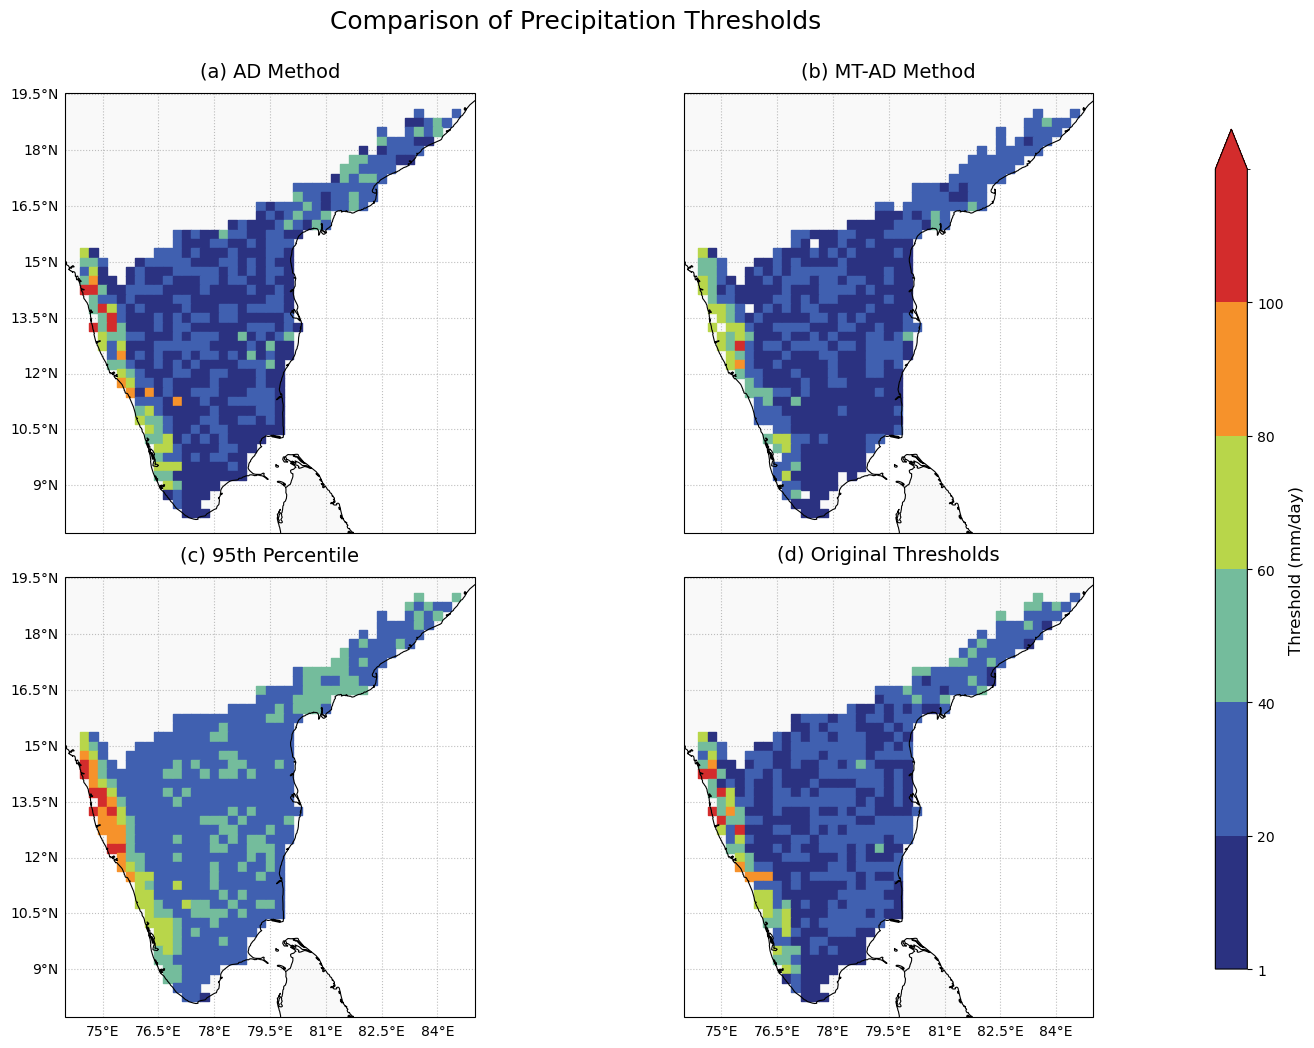

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# Color bar setting
levels = [1, 20, 40, 60, 80, 100, 120] # color levels range
colors = ['#2b3281', '#4060b0', '#74bc9c', '#b8d64a', '#f6922b', '#d32c2c']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, cmap.N)

# Data 
datasets = [final_thresholds_AD, final_thresholds_MTAD, percentil_thresholds_95, thresholds_origin]
titles = ['(a) AD Method', '(b) MT-AD Method', '(c) 95th Percentile', '(d) Original Thresholds']

# Drawing graph: 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Map component feature setting
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', zorder=4)
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')

    # Grid line setting
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # Label display
    if i % 2 != 0: 
        gl.left_labels = False
    if i < 2:     
        gl.bottom_labels = False

    # Data plotting
    sc = ax.scatter(lons, lats, c=datasets[i], 
                    cmap=cmap, 
                    norm=norm,
                    s=40,   
                    marker='s', 
                    transform=ccrs.PlateCarree(),
                    zorder=3)
    
    # Title
    ax.set_title(titles[i], fontsize=14, pad=12)

fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.1) 

# Shared Color bar setting
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='vertical', extend='max')
cbar.set_label('Threshold (mm/day)', fontsize=12)
cbar.set_ticks(levels[:-1])
cbar.ax.tick_params(labelsize=10)

plt.suptitle('Comparison of Precipitation Thresholds', fontsize=18, y=0.95)
plt.show()

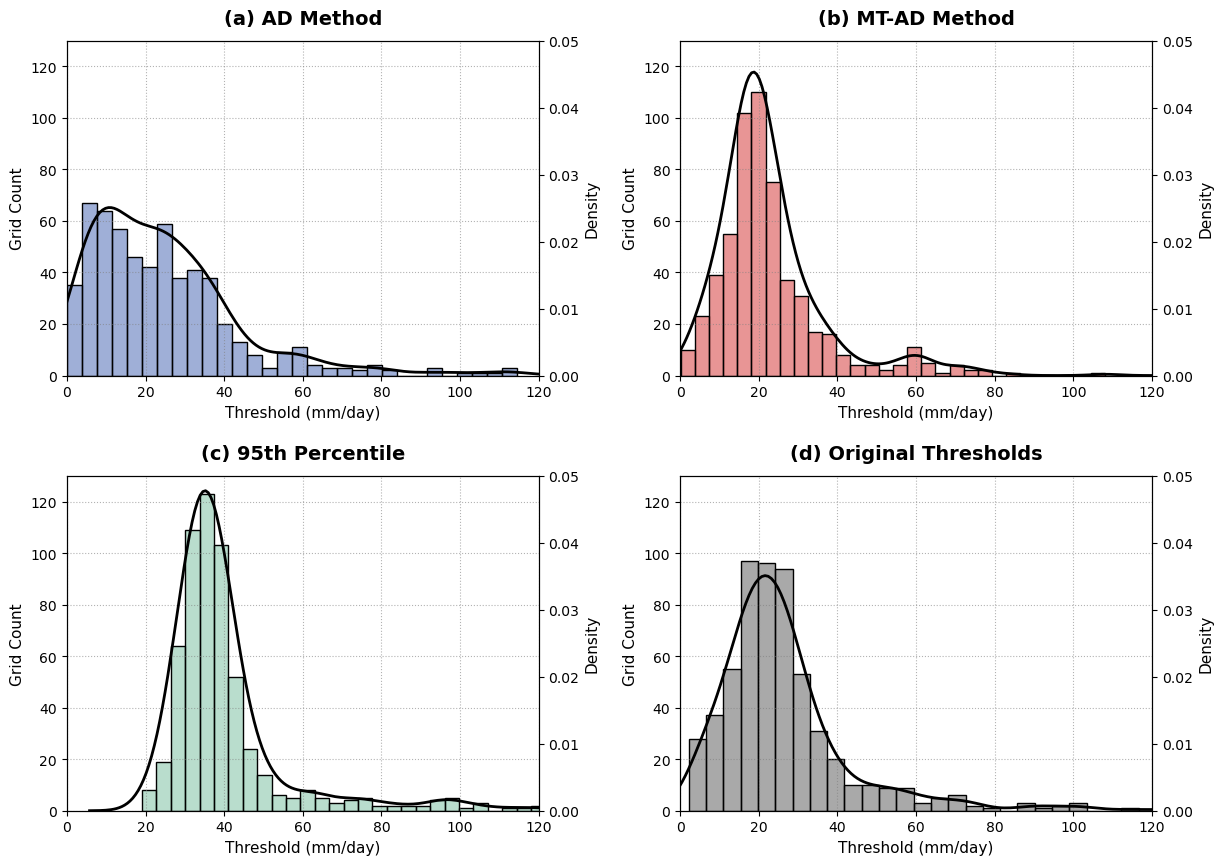

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (NaN 결측치 안전하게 제거)
datasets = [
    np.array(final_thresholds_AD)[~np.isnan(final_thresholds_AD)],
    np.array(final_thresholds_MTAD)[~np.isnan(final_thresholds_MTAD)],
    np.array(percentil_thresholds_95)[~np.isnan(percentil_thresholds_95)],
    np.array(thresholds_origin)[~np.isnan(thresholds_origin)]
]

titles = ['(a) AD Method', '(b) MT-AD Method', '(c) 95th Percentile', '(d) Original Thresholds']
colors = ['#4060b0', '#d32c2c', '#74bc9c', '#555555'] 

# 2. 그래프 그리기 (2x2 Subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 축 범위 고정값 설정
x_min, x_max = 0, 120
count_min, count_max = 0, 130       # 왼쪽 Y축 (Grid Count)
density_min, density_max = 0, 0.05  # 오른쪽 Y축 (Density)

for i, ax in enumerate(axes):
    # --- 1. 왼쪽 Y축: 막대 히스토그램 (Grid Count) ---
    sns.histplot(datasets[i], 
                 bins=30,             
                 stat='count',        # Y축을 실제 데이터 개수(Count)로 설정
                 color=colors[i], 
                 edgecolor='black',   
                 alpha=0.5,           
                 kde=False,           # 여기서 곡선은 뺌 (오른쪽 축에 따로 그릴 예정)
                 ax=ax)
    
    # --- 2. 오른쪽 Y축: 실선 곡선 (Density) ---
    ax_twin = ax.twinx()              # x축을 공유하는 새로운 y축 생성
    sns.kdeplot(datasets[i], 
                color='black',        # 곡선은 눈에 띄게 검은색으로 고정
                linewidth=2, 
                ax=ax_twin)
    
    # 타이틀 및 X축 라벨 설정
    ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Threshold (mm/day)', fontsize=11)
    
    # 왼쪽 Y축 (Count) 설정 및 통일
    ax.set_ylabel('Grid Count', fontsize=11)
    ax.set_ylim(count_min, count_max)
    
    # 오른쪽 Y축 (Density) 설정 및 통일
    ax_twin.set_ylabel('Density', fontsize=11)
    ax_twin.set_ylim(density_min, density_max)
    
    # X축 범위 통일
    ax.set_xlim(x_min, x_max)
    
    # 격자 설정 (왼쪽 축 기준)
    ax.grid(True, linestyle=':', alpha=0.6, color='gray')

# 서브플롯 간 간격 조정 (오른쪽 Y축 라벨이 잘리지 않도록 공간 확보)
fig.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

### 1-3. Threshold classification - 할지말지 고민중

### 1-4. EPE(Extreme Precipitation Events) Detection Results using Threshold

In [19]:
time_column_names = rain_data.columns[3:]
epe_values = []
epe_times = []
epe_dates = []

for i in range(rainfall.shape[0]):
    r = rainfall[i]
    is_extreme = r > thresholds_origin[i]
    epe_values.append(r[is_extreme])
    time_idx = np.where(is_extreme)[0]
    epe_times.append(time_idx)
    actual_dates = time_column_names[time_idx]
    epe_dates.append(actual_dates.tolist())

print(f"Grid 0의 EPE 발생 횟수: {len(epe_values[0])}")
print(f"Grid 0의 EPE 발생 강수량 5개: {epe_values[0][:5]}")
print(f"Grid 0의 EPE 발생 시간 인덱스 5개: {epe_times[0][:5]}")
print(f"Grid 0의 EPE 발생 실제 시간 5개: {epe_dates[0][:5]}")

Grid 0의 EPE 발생 횟수: 238
Grid 0의 EPE 발생 강수량 5개: [ 53.79999924 124.5         52.59999847  45.          51.29999924]
Grid 0의 EPE 발생 시간 인덱스 5개: [261 262 283 311 312]
Grid 0의 EPE 발생 실제 시간 5개: ['1951-09-19 00:00:00', '1951-09-20 00:00:00', '1951-10-11 00:00:00', '1951-11-08 00:00:00', '1951-11-09 00:00:00']


In [20]:
target_value = rain_data.at[0, '1951-11-08 00:00:00']
print(f"Grid 0의 1951-11-08 강수량 실제 값: {target_value} mm")

Grid 0의 1951-11-08 강수량 실제 값: 0.0 mm


## 2. Event Synchronization

In [ ]:
import numpy as np

def calculate_event_synchronization_exact(t_i, t_j, tau_max=8):
    """
    Event Synchronization calculating
    """
    n_i, n_j = len(t_i), len(t_j)
    
    if n_i < 2 or n_j < 2:
        return 0.0, 0.0

    # 1. 동적 타우(tau) 계산
    tau_i = np.empty(n_i)
    tau_i[0] = t_i[1] - t_i[0]
    tau_i[-1] = t_i[-1] - t_i[-2]
    tau_i[1:-1] = np.minimum(t_i[1:-1] - t_i[:-2], t_i[2:] - t_i[1:-1])

    tau_j = np.empty(n_j)
    tau_j[0] = t_j[1] - t_j[0]
    tau_j[-1] = t_j[-1] - t_j[-2]
    tau_j[1:-1] = np.minimum(t_j[1:-1] - t_j[:-2], t_j[2:] - t_j[1:-1])

    # 2. 시차 행렬 계산 (diff = t_j - t_i)
    diff_matrix = t_j[None, :] - t_i[:, None] 
    tau_matrix = 0.5 * np.minimum(tau_i[:, None], tau_j[None, :])
    
    # 3. 논문의 J_ij, J_ji 수식 완벽 적용
    
    # 수식 1: j가 먼저 발생하고 i가 나중에 발생 (t_i > t_j 즉, diff < 0)
    # 이미지의 J_ij 수식: 0 < t_i - t_j <= tau 
    # c(i|j)에 합산
    mask_ij = (diff_matrix < 0) & (-diff_matrix <= tau_max) & (-diff_matrix <= tau_matrix)
    c_ij = np.sum(mask_ij)
    
    # 수식 2: i가 먼저 발생하고 j가 나중에 발생 (t_j > t_i 즉, diff > 0)
    # 이미지의 J_ji 수식: 0 < t_j - t_i <= tau
    # c(j|i)에 합산
    mask_ji = (diff_matrix > 0) & (diff_matrix <= tau_max) & (diff_matrix <= tau_matrix)
    c_ji = np.sum(mask_ji)
    
    # 수식 3: 동시 발생 (t_i == t_j 즉, diff == 0)
    # J_ij, J_ji 모두 1/2 부여
    sync_same_day = np.sum(diff_matrix == 0)
    c_ij += 0.5 * sync_same_day
    c_ji += 0.5 * sync_same_day
    
    return c_ij, c_ji

# 전체 행렬 구축
num_grids = len(epe_times)
C_matrix = np.zeros((num_grids, num_grids)) 

for i in range(num_grids):
    for j in range(num_grids):
        if i == j:
            break
        c_ij, c_ji = calculate_event_synchronization_exact(epe_times[i], epe_times[j], tau_max=8)
        C_matrix[i, j] = c_ij
        C_matrix[j, i] = c_ji 

print("Event Synchronization 행렬 계산 및 논문 방향성 매핑 완료!")

Event Synchronization 행렬 계산 및 논문 방향성 매핑 완료!


In [27]:
print(C_matrix.shape)

(578, 578)


In [28]:
# 1. 각 그리드별 이벤트 발생 총 횟수(s) 계산
num_grids = len(epe_times)
s_array = np.array([len(times) for times in epe_times])

# 2. 수식의 분모에 해당하는 sqrt(s_i * s_j) 행렬 계산 (브로드캐스팅 활용)
denominator = np.sqrt(s_array[:, None] * s_array[None, :])

# 3. 0으로 나누는 오류를 방지하기 위해 분모가 0보다 큰(유효한) 위치 찾기
valid_mask = denominator > 0

# 4. 빈 행렬 초기화
Q_matrix = np.zeros((num_grids, num_grids))
q_matrix = np.zeros((num_grids, num_grids))

# 5. Q 행렬 (동기화 강도) 계산 
# C_matrix.T 는 행렬을 뒤집은 것(Transpose)으로, C_matrix.T[i, j]는 C_matrix[j, i]와 같습니다.
Q_matrix[valid_mask] = (C_matrix[valid_mask] + C_matrix.T[valid_mask]) / denominator[valid_mask]

# 6. q 행렬 (지연 방향) 계산
q_matrix[valid_mask] = (C_matrix[valid_mask] - C_matrix.T[valid_mask]) / denominator[valid_mask]

# 7. 행렬 대각 성분 처리 (자기 자신과의 관계)
# 자기 자신과의 동기화 강도(Q)는 1, 시차(q)는 0이 되어야 합니다.
np.fill_diagonal(Q_matrix, 1.0)
np.fill_diagonal(q_matrix, 0.0)

print("Q 행렬 및 q 행렬 계산 완료!")
print(f"Q_matrix 형태: {Q_matrix.shape}")
print(f"q_matrix 형태: {q_matrix.shape}")

# 결과 확인용 출력 (행렬의 최대/최소값 확인)
print(f"Q_matrix 최댓값: {np.max(Q_matrix):.4f}, 최솟값: {np.min(Q_matrix):.4f}")
print(f"q_matrix 최댓값: {np.max(q_matrix):.4f}, 최솟값: {np.min(q_matrix):.4f}")

Q 행렬 및 q 행렬 계산 완료!
Q_matrix 형태: (578, 578)
q_matrix 형태: (578, 578)
Q_matrix 최댓값: 1.0000, 최솟값: 0.0032
q_matrix 최댓값: 0.1267, 최솟값: -0.1267


히트맵 그래프가 'ES_Q_q_matrices.png'로 저장되었습니다.


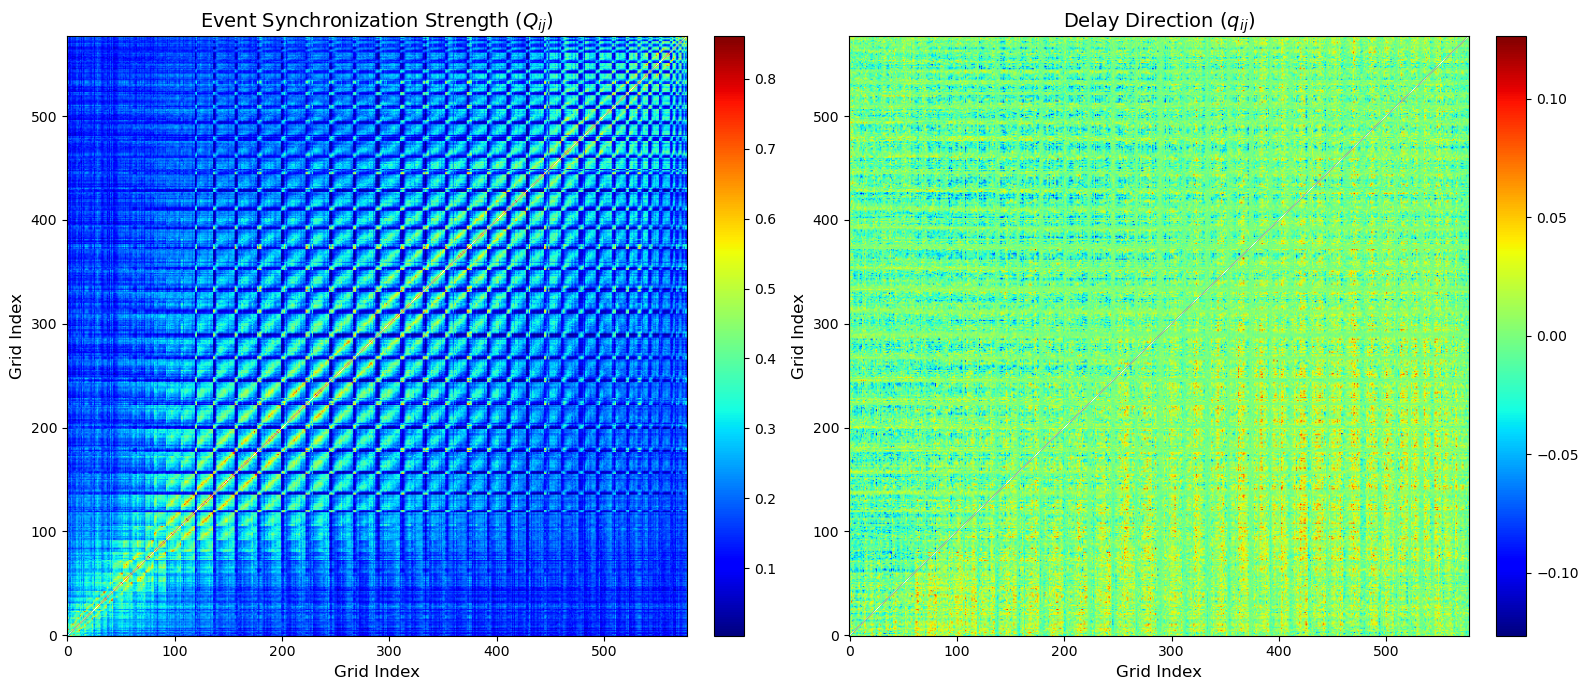

In [29]:
# 시각화를 위해 원본 데이터를 보존하고 복사본을 생성합니다.
Q_plot = Q_matrix.copy()
q_plot = q_matrix.copy()

# 시각화 색상 스케일 왜곡을 막기 위해 대각선 성분을 NaN으로 처리합니다.
np.fill_diagonal(Q_plot, np.nan)
np.fill_diagonal(q_plot, np.nan)

# 그림 사이즈 설정 (가로로 길게 두 개의 그래프 배치)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Q 행렬 (동기화 강도) 시각화
# Q는 0에서 1 사이의 양수 값이므로 일반적인 컬러맵 적용
im_Q = axes[0].imshow(Q_plot, cmap='jet', origin='lower', aspect='auto')
axes[0].set_title('Event Synchronization Strength ($Q_{ij}$)', fontsize=14)
axes[0].set_xlabel('Grid Index', fontsize=12)
axes[0].set_ylabel('Grid Index', fontsize=12)
fig.colorbar(im_Q, ax=axes[0], fraction=0.046, pad=0.04)

# 2. q 행렬 (지연 방향) 시각화
# q는 음수와 양수를 모두 가지므로 0을 중심으로 대칭적인 컬러 스케일 적용 (vmax, vmin 설정)
vmax = np.nanmax(np.abs(q_plot)) # 데이터 중 절대값이 가장 큰 값을 찾습니다.
im_q = axes[1].imshow(q_plot, cmap='jet', origin='lower', aspect='auto', 
                      vmin=-vmax, vmax=vmax) # 0을 기준으로 대칭 분포
axes[1].set_title('Delay Direction ($q_{ij}$)', fontsize=14)
axes[1].set_xlabel('Grid Index', fontsize=12)
axes[1].set_ylabel('Grid Index', fontsize=12)
cbar_q = fig.colorbar(im_q, ax=axes[1], fraction=0.046, pad=0.04)

# 레이아웃 조정 및 그래프 저장
plt.tight_layout()
plt.savefig('ES_Q_q_matrices.png', dpi=300)
print("히트맵 그래프가 'ES_Q_q_matrices.png'로 저장되었습니다.")

## 3. Precipitation Network construction

### 3-1. Clustering by 3.Malik (2010)

계층적 군집화 및 덴드로그램 생성 완료!
불일치 계수 임계값: 1.1547
노이즈 필터링 후 도출된 최종 유효 군집(Coherent Zones) 개수: 7개


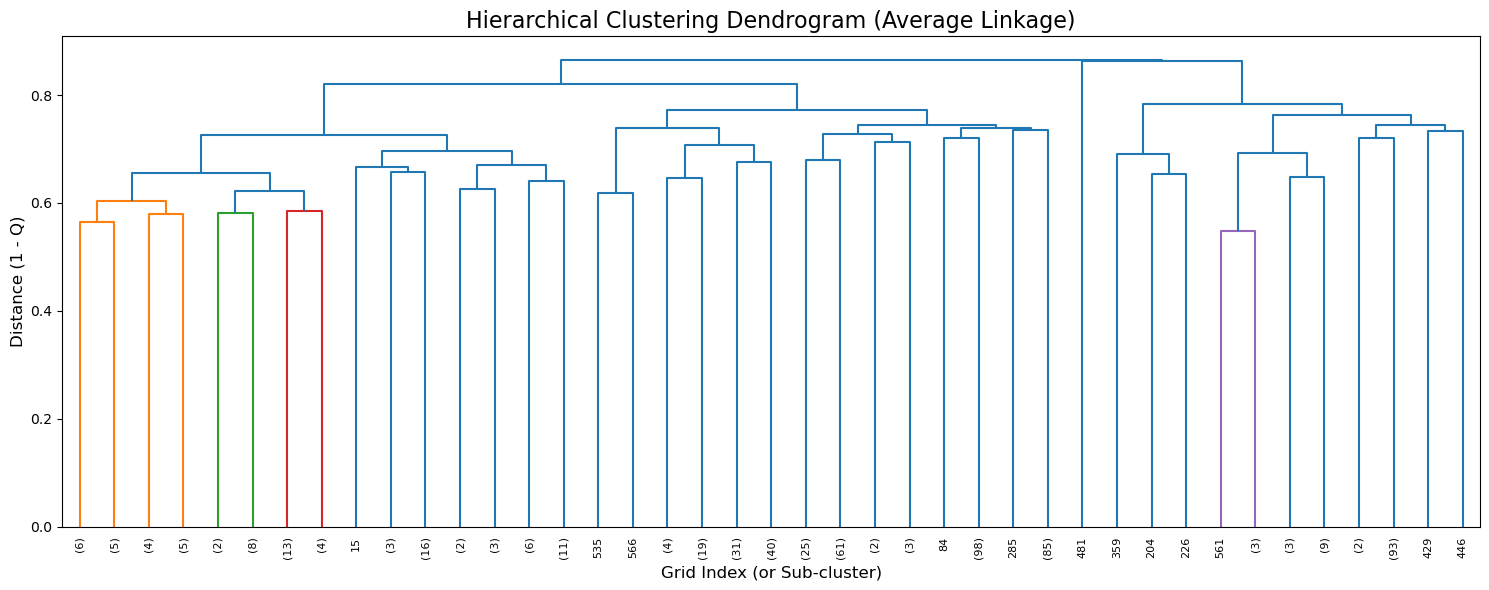

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram, inconsistent, fcluster
from scipy.spatial.distance import squareform

# 1. 비유사성(거리) 행렬 계산: d(j,k) = 1 - Q_jk
D_matrix = 1.0 - Q_matrix

# 대각선 성분(자기 자신과의 거리)은 0으로 설정
np.fill_diagonal(D_matrix, 0.0)

# 부동소수점 오차로 인한 비대칭성을 방지하기 위해 완벽한 대칭 행렬로 보정
D_matrix = (D_matrix + D_matrix.T) / 2.0

# SciPy 계층적 군집화 함수에 넣기 위해 1차원 축소 행렬(Condensed Distance Matrix)로 변환
condensed_D = squareform(D_matrix)

# 2. 계층적 군집화 수행 (평균 연결법: Average Linkage)
Z = linkage(condensed_D, method='average')

# 3. 불일치 계수(Inconsistency Coefficient) 계산
# depth=2는 inconsistency를 계산하는 기본 깊이로, 논문의 일반적 설정을 따름
incons = inconsistent(Z, d=2)

# 논문 기준: "second highest value of the inconsistency coefficient"에서 트리 자르기
# incons 배열의 4번째 열(인덱스 3)이 불일치 계수 값입니다.
incons_values = np.unique(incons[:, 3])
second_highest_incons = incons_values[-2] # 두 번째로 높은 고유값 도출

# 해당 임계값으로 군집(Cluster) 형성
clusters = fcluster(Z, t=second_highest_incons, criterion='inconsistent')

# 4. 노이즈 필터링 (격자 3개 미만인 소규모 군집 제거)
unique_clusters, counts = np.unique(clusters, return_counts=True)
valid_clusters = unique_clusters[counts >= 3]

# 유효하지 않은 군집(크기 3 미만)은 -1로 라벨링하여 버림 처리
final_clusters = np.where(np.isin(clusters, valid_clusters), clusters, -1)

# 유효한 군집 번호를 1부터 순차적으로 재배열
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(valid_clusters, 1)}
final_clusters = np.array([cluster_mapping.get(c, -1) for c in final_clusters])

# 5. 덴드로그램(트리 구조) 시각화
plt.figure(figsize=(15, 6))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)", fontsize=16)
plt.xlabel("Grid Index (or Sub-cluster)", fontsize=12)
plt.ylabel("Distance (1 - Q)", fontsize=12)

# 가독성을 위해 맨 아래 노드들을 적당히 생략(truncate)해서 표시
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)

plt.tight_layout()
plt.savefig("Hierarchical_Dendrogram.png", dpi=300)

print("계층적 군집화 및 덴드로그램 생성 완료!")
print(f"불일치 계수 임계값: {second_highest_incons:.4f}")
print(f"노이즈 필터링 후 도출된 최종 유효 군집(Coherent Zones) 개수: {len(valid_clusters)}개")

네트워크 패턴 및 방향성(Vector) 시각화 완료! 'Monsoon_Network_Patterns_Final.png' 파일로 저장되었습니다.


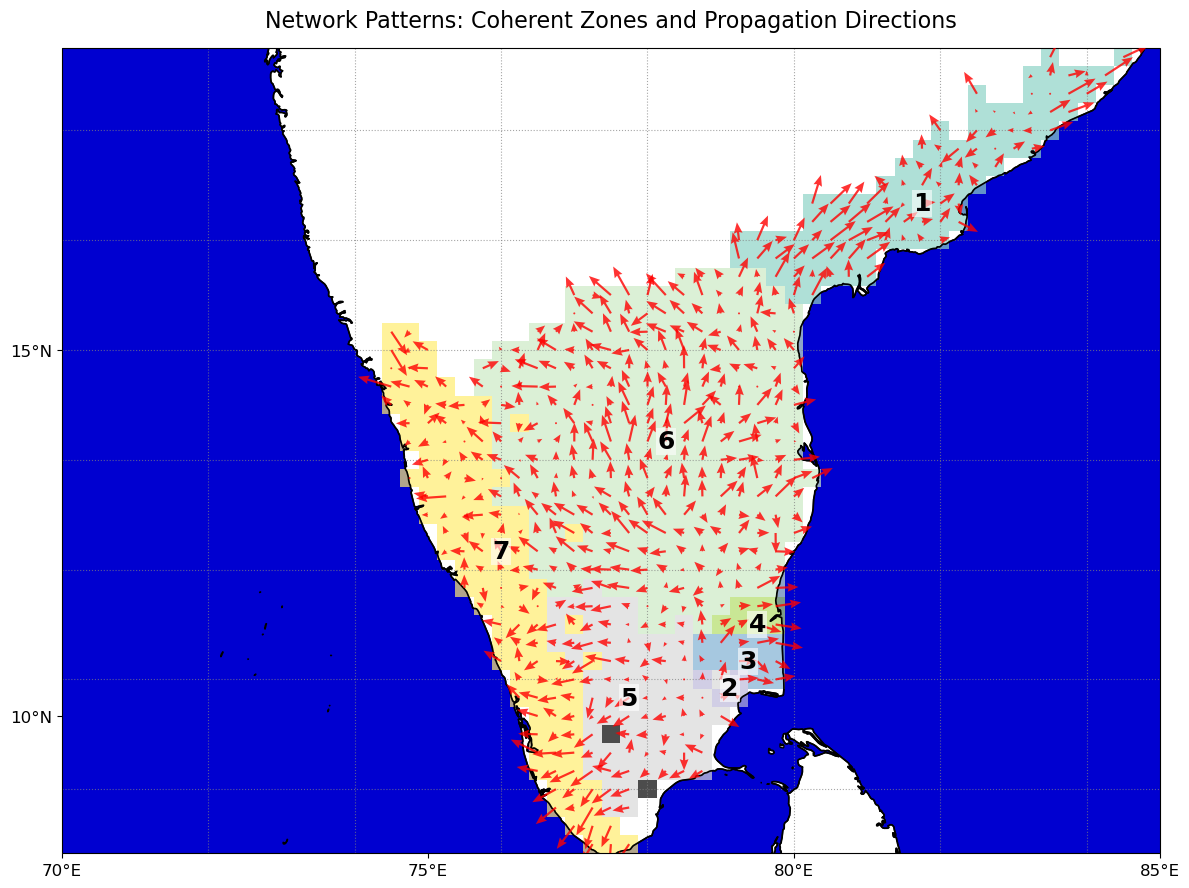

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# -------------------------------------------------------------------
# 1. 이동 방향 벡터(U, V) 계산 (Malik 2010, Eq. 8 논리 적용)
# -------------------------------------------------------------------
num_grids = len(lons)
U = np.zeros(num_grids)
V = np.zeros(num_grids)

# 인접 격자 탐색 반경 (1도 해상도 데이터 기준, 대각선 이웃을 포함하기 위해 1.5도로 설정)
search_radius = 1.5 

for i in range(num_grids):
    # 현재 그리드(i)와 다른 모든 그리드 사이의 거리 계산
    dist = np.sqrt((lons - lons[i])**2 + (lats - lats[i])**2)
    # 주변 8방향 인접 이웃 탐색 (자기 자신 제외)
    neighbors = np.where((dist > 0) & (dist <= search_radius))[0]
    
    u_i, v_i = 0.0, 0.0
    weight_sum = 0.0
    
    for j in neighbors:
        dx = lons[j] - lons[i]
        dy = lats[j] - lats[i]
        
        # q_matrix[i, j]가 양수이면 j가 i보다 먼저 발생 (흐름: j -> i, 즉 -dx, -dy 방향)
        # q_matrix[i, j]가 음수이면 i가 j보다 먼저 발생 (흐름: i -> j, 즉 dx, dy 방향)
        # 따라서 흐름 벡터 성분은 -q_matrix[i, j] * (dx, dy)가 됩니다.
        weight = -q_matrix[i, j]
        
        u_i += weight * dx
        v_i += weight * dy
        weight_sum += abs(weight)
        
    # 벡터 평균 (정규화)
    if weight_sum > 0:
        U[i] = u_i / weight_sum
        V[i] = v_i / weight_sum

# -------------------------------------------------------------------
# 2. 군집화 지도 + 벡터 필드 시각화
# -------------------------------------------------------------------
# (앞서 작성한 배경 지도 및 pcolormesh 군집화 코드 재사용)
plot_clusters = np.where(final_clusters == -1, 0, final_clusters)
df = pd.DataFrame({'lon': lons, 'lat': lats, 'cluster': plot_clusters})
grid_data = df.pivot(index='lat', columns='lon', values='cluster')

lon_mesh, lat_mesh = np.meshgrid(grid_data.columns, grid_data.index)
cluster_grid = grid_data.values

num_clusters = len(np.unique(final_clusters[final_clusters > 0]))
cmap_base = plt.get_cmap('Set3', num_clusters)
colors = ['black'] + [cmap_base(i) for i in range(num_clusters)]
custom_cmap = mcolors.ListedColormap(colors)

bounds = np.arange(-0.5, num_clusters + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#0000D0', zorder=0) 
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='black', zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=3)

# 면 채우기 (군집)
mesh = ax.pcolormesh(lon_mesh, lat_mesh, cluster_grid, 
                     cmap=custom_cmap, norm=norm, shading='nearest', 
                     transform=ccrs.PlateCarree(), zorder=1, alpha=0.7)

# 화살표 덧그리기 (Vector Field)
# 화살표가 너무 빽빽하면 보기 힘들 수 있으므로 노이즈(-1) 지역이 아닌 곳에만 화살표를 표시합니다.
valid_idx = (final_clusters != -1) & ((U != 0) | (V != 0))

# quiver 함수를 이용한 벡터 필드 시각화 (논문 Figure 7 재현)
q_plot = ax.quiver(lons[valid_idx], lats[valid_idx], U[valid_idx], V[valid_idx],
                   transform=ccrs.PlateCarree(),
                   color='red',           # 화살표 색상 (배경과 대비되도록 붉은색)
                   scale=25,              # 화살표 길이 조절 (숫자가 작을수록 화살표가 길어짐)
                   width=0.002,           # 화살표 두께
                   headwidth=4,           # 화살표 머리 너비
                   alpha=0.8, zorder=4)

# 군집 번호 텍스트
for cluster_id in range(1, num_clusters + 1):
    mask = (final_clusters == cluster_id)
    if np.any(mask):
        mean_lon = np.median(lons[mask])
        mean_lat = np.median(lats[mask])
        ax.text(mean_lon, mean_lat, str(cluster_id), 
                transform=ccrs.PlateCarree(), fontsize=18, fontweight='bold', 
                ha='center', va='center', color='black', 
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1), zorder=5)

ax.set_xticks(np.arange(70, 90, 5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 20, 5), crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(axis='both', labelsize=12)
ax.gridlines(draw_labels=False, linestyle=':', color='gray', alpha=0.7)

plt.title('Network Patterns: Coherent Zones and Propagation Directions', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig('Monsoon_Network_Patterns_Final.png', dpi=300)
print("네트워크 패턴 및 방향성(Vector) 시각화 완료! 'Monsoon_Network_Patterns_Final.png' 파일로 저장되었습니다.")

### 3-2. Null models by 4. boers (2016) & Kaiwen(2024)

#### 1. Network Divergence

In [40]:
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed

# 1. 널 모델용 워커 함수 (양방향 통합 계산)
def worker_function(s_pair, total_time_steps, num_surrogates=20, percentile=95):
    s1, s2 = s_pair # 항상 s1 <= s2 로 정렬된 상태로 들어옴
    
    fake_scores_12 = np.zeros(num_surrogates)
    fake_scores_21 = np.zeros(num_surrogates)
    
    for k in range(num_surrogates):
        # 1번의 셔플링으로 두 개의 배열 생성
        fake_t1 = np.sort(np.random.choice(total_time_steps, s1, replace=False))
        fake_t2 = np.sort(np.random.choice(total_time_steps, s2, replace=False))
        
        # 1번의 함수 호출로 양방향 동기화 점수 동시 획득
        c_12, c_21 = calculate_event_synchronization_exact(fake_t1, fake_t2, tau_max=8)
        
        fake_scores_12[k] = c_12
        fake_scores_21[k] = c_21
        
    # 두 방향에 대한 95% 임계값을 각각 도출하여 딕셔너리로 동시 반환
    thresh_12 = np.percentile(fake_scores_12, percentile)
    thresh_21 = np.percentile(fake_scores_21, percentile)
    
    return {
        (s1, s2): thresh_12,
        (s2, s1): thresh_21
    }

# =====================================================================
# 메인 실행부
# =====================================================================

# 데이터셋 전체 시간 스텝 산출
max_time_index = 0
for times in epe_times:
    if len(times) > 0:
        max_time_index = max(max_time_index, int(np.max(times)))
total_time_steps = max_time_index + 1

num_grids = len(epe_times)
s_array = np.array([len(times) for times in epe_times])

# 2. 실제로 필요한 (si, sj) 조합만 추출하고, 방향성 중복을 제거 (정렬된 튜플 사용)
required_s_pairs = set()

# C_matrix의 값이 0보다 큰 인덱스만 추출하여 불필요한 반복문 제거
i_indices, j_indices = np.nonzero(C_matrix)

for i, j in zip(i_indices, j_indices):
    if i != j and s_array[i] >= 2 and s_array[j] >= 2:
        si, sj = s_array[i], s_array[j]
        # 크기 순으로 정렬하여 set에 넣으면 (5, 10)과 (10, 5)가 (5, 10) 하나로 통합됨
        required_s_pairs.add(tuple(sorted((si, sj))))

print(f"최적화 적용: 실제 병렬 계산할 고유 조합 수 = {len(required_s_pairs)}개")

# 3. Joblib 병렬 처리 실행 (가용 코어 100% 활용)
# n_jobs=-1 은 모든 코어를 최대치로 사용한다는 의미입니다.
results = Parallel(n_jobs=-1)(
    delayed(worker_function)(pair, total_time_steps, 20, 95) 
    for pair in tqdm(list(required_s_pairs))
)

# 리스트 형태로 반환된 여러 개의 딕셔너리를 하나의 통합 딕셔너리로 병합
lookup_table = {}
for res in results:
    lookup_table.update(res)

# 4. A_matrix 구축 (uint8로 메모리 최소화, 그룹 단위 처리)
A_matrix = np.zeros((num_grids, num_grids), dtype=np.uint8)

# 이미 뽑아둔 0이 아닌 C_matrix 인덱스만 순회하여 A_matrix 채우기
for i, j in zip(i_indices, j_indices):
    if i != j and s_array[i] >= 2 and s_array[j] >= 2:
        si, sj = s_array[i], s_array[j]
        # 저장된 양방향 Lookup Table에서 즉시 임계값 확인
        if C_matrix[i, j] > lookup_table[(si, sj)]:
            A_matrix[i, j] = 1

# 5. Network Divergence 계산
k_out = np.sum(A_matrix, axis=1)
k_in = np.sum(A_matrix, axis=0)
network_divergence = k_out - k_in

print("\n최적화된 Adjacency Matrix 구축 및 Network Divergence 계산 종료!")
print(f"유의미한 연결선(Edge)의 수: {np.sum(A_matrix)}개")
print(f"가장 강한 Source 격자의 Divergence 점수: {np.max(network_divergence)}")
print(f"가장 강한 Sink 격자의 Divergence 점수: {np.min(network_divergence)}")

최적화 적용: 실제 병렬 계산할 고유 조합 수 = 79129개


100%|██████████| 79129/79129 [51:13<00:00, 25.75it/s]



최적화된 Adjacency Matrix 구축 및 Network Divergence 계산 종료!
유의미한 연결선(Edge)의 수: 58890개
가장 강한 Source 격자의 Divergence 점수: 18446744073709551615
가장 강한 Sink 격자의 Divergence 점수: 0


In [45]:
# A_matrix의 합산 결과를 부호가 있는 일반 정수(int32 또는 int64)로 강제 변환합니다.
k_out = np.sum(A_matrix, axis=1).astype(int)
k_in = np.sum(A_matrix, axis=0).astype(int)

# 이제 음수 계산이 정상적으로 수행됩니다.
network_divergence = k_out - k_in

print("Divergence 오류 수정 완료!")
print(f"유의미한 연결선(Edge)의 수: {np.sum(A_matrix)}개")
print(f"가장 강한 Source 격자의 Divergence 점수: {np.max(network_divergence)}")
print(f"가장 강한 Sink 격자의 Divergence 점수: {np.min(network_divergence)}")

Divergence 오류 수정 완료!
유의미한 연결선(Edge)의 수: 58890개
가장 강한 Source 격자의 Divergence 점수: 73
가장 강한 Sink 격자의 Divergence 점수: -101


Network Divergence 지도 시각화 완료! 'Network_Divergence_Map.png' 파일로 저장되었습니다.


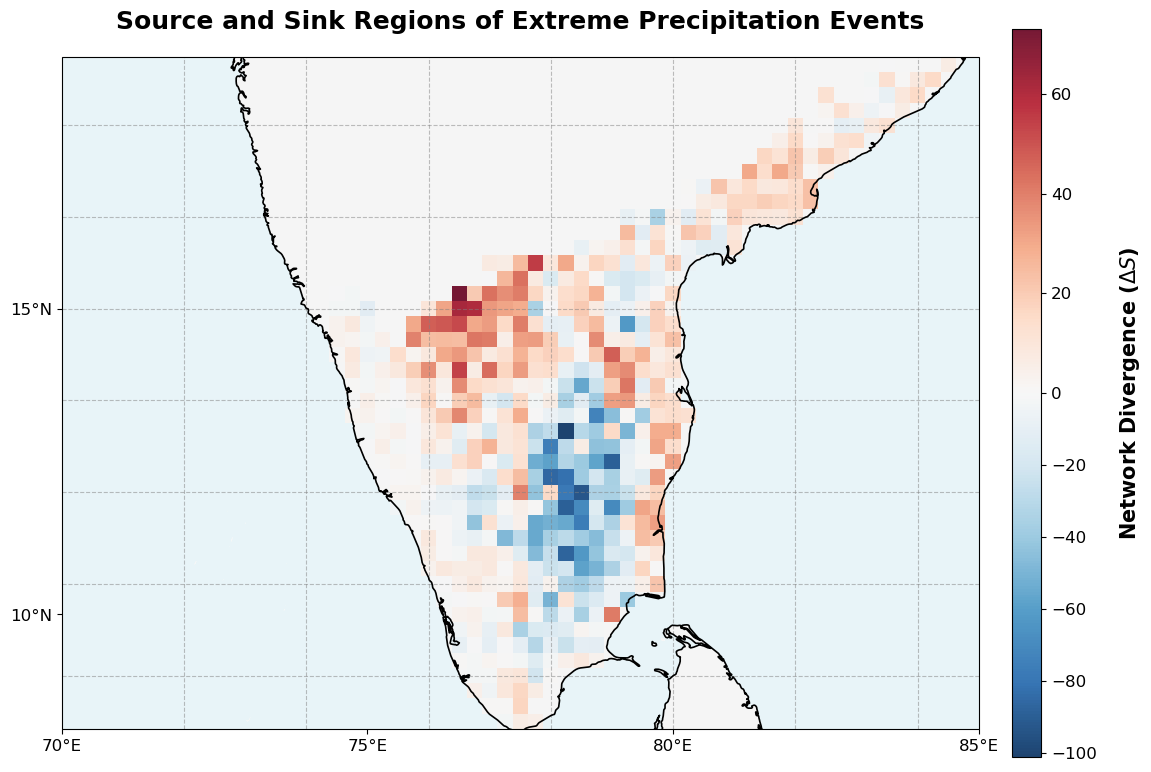

In [46]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# 1. 1차원 Divergence 배열을 2차원 격자(Grid)로 변환
df_div = pd.DataFrame({'lon': lons, 'lat': lats, 'divergence': network_divergence})
grid_div = df_div.pivot(index='lat', columns='lon', values='divergence')

lon_mesh, lat_mesh = np.meshgrid(grid_div.columns, grid_div.index)
div_grid = grid_div.values

# 2. 색상표(Colormap) 및 정규화(Normalization) 설정
# 양수(Source)는 붉은색, 음수(Sink)는 푸른색, 0은 흰색이 되도록 밸런스를 맞춥니다.
vmax = np.nanmax(div_grid)
vmin = np.nanmin(div_grid)

# vmin과 vmax가 모두 양수이거나 음수일 경우를 대비한 안전장치
if vmax <= 0: vmax = 1 
if vmin >= 0: vmin = -1

# 0을 정확히 컬러맵의 중앙(white)에 위치시키는 TwoSlopeNorm 사용
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.get_cmap('RdBu_r') # Red-Blue reversed (Red가 양수, Blue가 음수)

# 3. 지도 생성 및 배경 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 대조를 위해 바다는 아주 연한 하늘색, 육지 배경은 밝은 회색으로 설정
ax.add_feature(cfeature.OCEAN, facecolor='#E8F4F8', zorder=0) 
ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1.2, edgecolor='black', zorder=3)

# 4. 2차원 격자 데이터 시각화 (면 채우기)
mesh = ax.pcolormesh(lon_mesh, lat_mesh, div_grid, 
                     cmap=cmap, norm=norm, shading='nearest', 
                     transform=ccrs.PlateCarree(), zorder=1, alpha=0.9)

# 5. 컬러바(Colorbar) 추가
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.75, aspect=25)
cbar.set_label('Network Divergence ($\Delta S$)', fontsize=15, labelpad=15, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# 6. 축 라벨 및 눈금선 포맷팅
ax.set_xticks(np.arange(70, 90, 5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 20, 5), crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(axis='both', labelsize=12)
ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.5, zorder=2)

plt.title('Source and Sink Regions of Extreme Precipitation Events', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('Network_Divergence_Map.png', dpi=300)
print("Network Divergence 지도 시각화 완료! 'Network_Divergence_Map.png' 파일로 저장되었습니다.")

#### 2. Network degree

Total Degree 지도 시각화 완료! 'Network_Total_Degree_Map.png' 파일로 저장되었습니다.


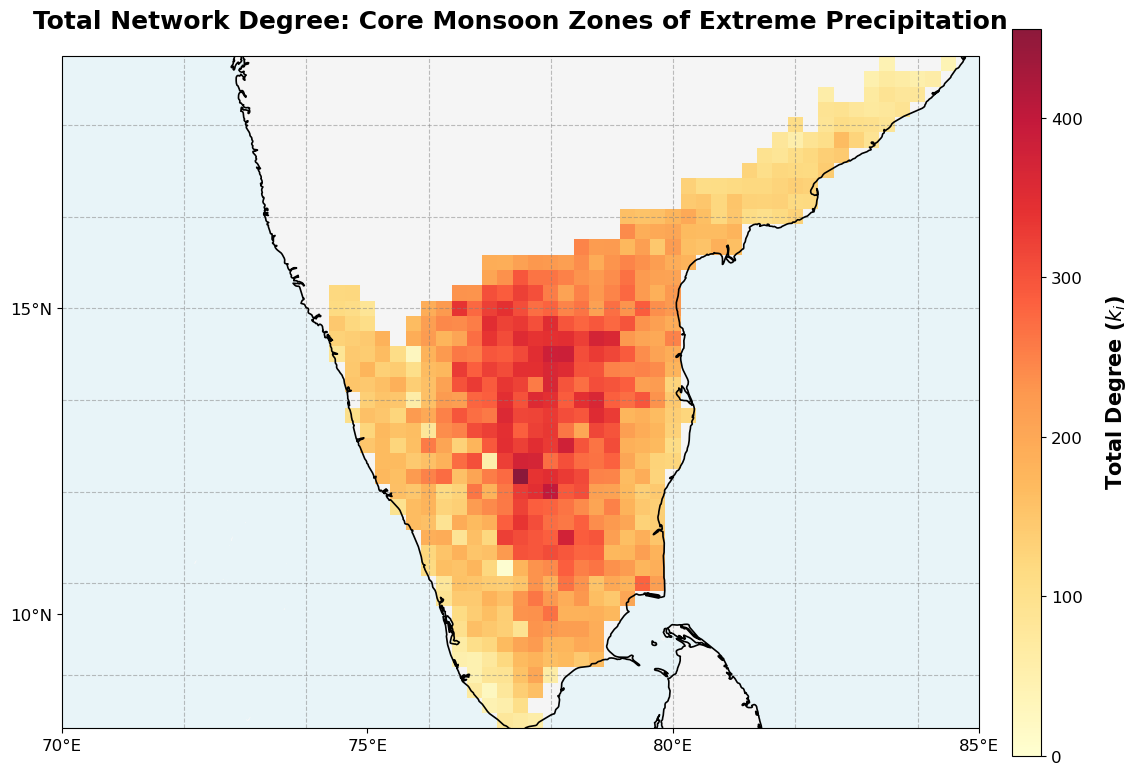

In [47]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import pandas as pd

# 1. Total Degree 계산 (들어오는 선 + 나가는 선)
# A_matrix는 앞서 널 모델을 통해 1과 0으로 만들어진 인접 행렬입니다.
total_degree = np.sum(A_matrix, axis=0) + np.sum(A_matrix, axis=1)

# 2. 1차원 Degree 배열을 2차원 격자(Grid)로 변환
df_deg = pd.DataFrame({'lon': lons, 'lat': lats, 'degree': total_degree})
grid_deg = df_deg.pivot(index='lat', columns='lon', values='degree')

lon_mesh, lat_mesh = np.meshgrid(grid_deg.columns, grid_deg.index)
deg_grid = grid_deg.values

# 3. 지도 생성 및 배경 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#E8F4F8', zorder=0) 
ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1.2, edgecolor='black', zorder=3)

# 4. Total Degree 데이터 시각화 (면 채우기)
# 값의 크기에 따라 시각적 효과를 주기 위해 YlGnBu 컬러맵 사용 (높을수록 진한 색)
mesh = ax.pcolormesh(lon_mesh, lat_mesh, deg_grid, 
                     cmap='YlOrRd', shading='nearest', 
                     transform=ccrs.PlateCarree(), zorder=1, alpha=0.9)

# 5. 컬러바 추가
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.75, aspect=25)
cbar.set_label('Total Degree ($k_i$)', fontsize=15, labelpad=15, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# 6. 축 라벨 포맷팅
ax.set_xticks(np.arange(70, 90, 5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 20, 5), crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(axis='both', labelsize=12)
ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.5, zorder=2)

plt.title('Total Network Degree: Core Monsoon Zones of Extreme Precipitation', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('Network_Total_Degree_Map.png', dpi=300)
print("Total Degree 지도 시각화 완료! 'Network_Total_Degree_Map.png' 파일로 저장되었습니다.")

#### partial degree

설정된 타겟 구역(Region R) 내의 격자 수: 60개
Partial Degree 지도 시각화 완료! 'Network_Partial_Degree_Map.png' 파일로 저장되었습니다.


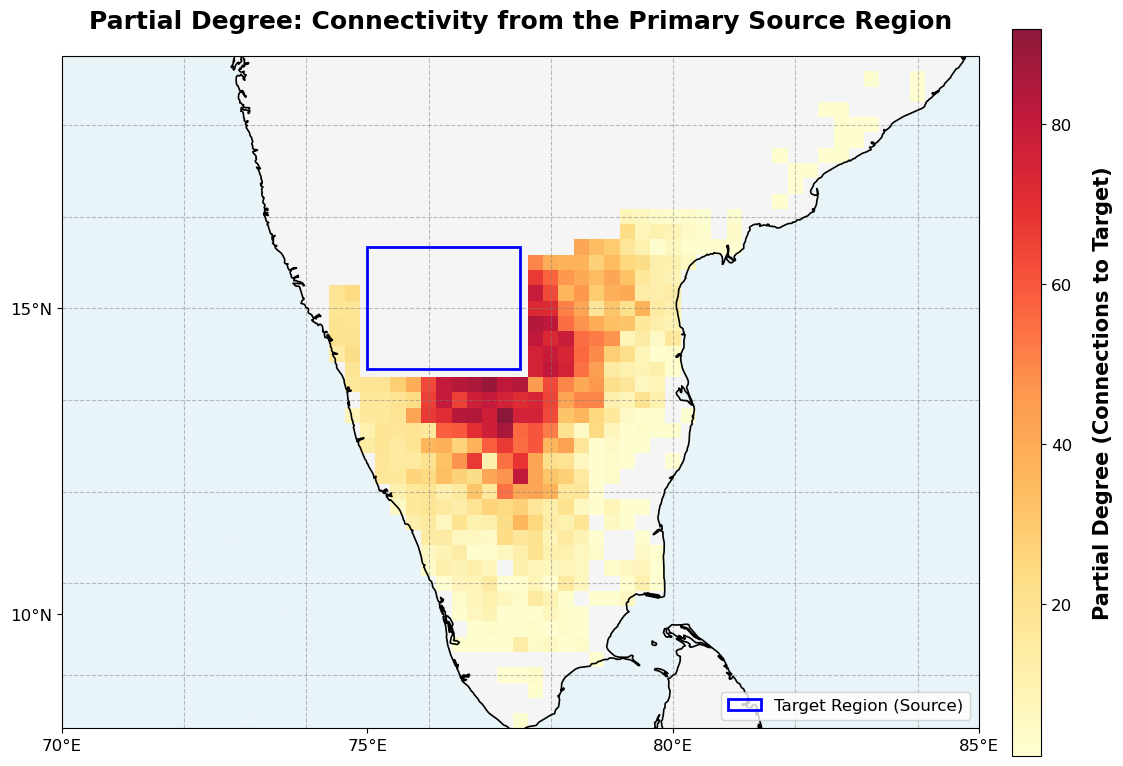

In [48]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np
import pandas as pd

# 1. 타겟 구역(Region R: 강력한 Source 지역) 설정
# 지도에서 가장 붉은색이 진했던 카르나타카 북부 내륙 지역
lat_min, lat_max = 14.0, 16.0
lon_min, lon_max = 75.0, 77.5

# 타겟 구역에 속하는 격자들의 인덱스 추출
region_R_indices = np.where((lats >= lat_min) & (lats <= lat_max) & 
                            (lons >= lon_min) & (lons <= lon_max))[0]

print(f"설정된 타겟 구역(Region R) 내의 격자 수: {len(region_R_indices)}개")

# 2. 부분 연결수(Partial Degree) 계산
# Region R 내의 노드들과 다른 모든 외부 노드 i 사이의 총 연결(in + out) 횟수 계산
partial_degree = np.zeros(num_grids)

for i in range(num_grids):
    if i not in region_R_indices:
        # 노드 i와 Region R에 속한 노드들 간의 연결 합산
        # A_matrix[i, j]: i -> j 방향, A_matrix[j, i]: j -> i 방향
        links_to_R = np.sum(A_matrix[i, region_R_indices])
        links_from_R = np.sum(A_matrix[region_R_indices, i])
        partial_degree[i] = links_to_R + links_from_R

# 3. 1차원 Partial Degree 배열을 2차원 격자(Grid)로 변환
df_pdeg = pd.DataFrame({'lon': lons, 'lat': lats, 'partial_degree': partial_degree})
grid_pdeg = df_pdeg.pivot(index='lat', columns='lon', values='partial_degree')

lon_mesh, lat_mesh = np.meshgrid(grid_pdeg.columns, grid_pdeg.index)
pdeg_grid = grid_pdeg.values

# 4. 지도 생성 및 배경 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#E8F4F8', zorder=0) 
ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1.2, edgecolor='black', zorder=3)

# 5. Partial Degree 데이터 시각화 (0인 곳은 투명하게 처리하여 연관된 곳만 강조)
masked_pdeg_grid = np.ma.masked_where(pdeg_grid == 0, pdeg_grid)
mesh = ax.pcolormesh(lon_mesh, lat_mesh, masked_pdeg_grid, 
                     cmap='YlOrRd', shading='nearest', 
                     transform=ccrs.PlateCarree(), zorder=1, alpha=0.9)

# 타겟 구역(Region R)을 지도에 파란색 박스로 표시
import matplotlib.patches as mpatches
rect = mpatches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min, 
                          linewidth=2, edgecolor='blue', facecolor='none', 
                          transform=ccrs.PlateCarree(), zorder=5, label='Target Region (Source)')
ax.add_patch(rect)

# 6. 컬러바 및 축 설정
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.75, aspect=25)
cbar.set_label('Partial Degree (Connections to Target)', fontsize=15, labelpad=15, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(np.arange(70, 90, 5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(10, 20, 5), crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(axis='both', labelsize=12)
ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.5, zorder=2)
ax.legend(loc='lower right', fontsize=12)

plt.title('Partial Degree: Connectivity from the Primary Source Region', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('Network_Partial_Degree_Map.png', dpi=300)
print("Partial Degree 지도 시각화 완료! 'Network_Partial_Degree_Map.png' 파일로 저장되었습니다.")

## 3. ENSO analysis

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# =====================================================================
# 1. 널 모델용 워커 함수 (수정됨: 전체 기간이 아닌 유효 기간 안에서만 셔플)
# =====================================================================
def worker_function(s_pair, valid_days, num_surrogates=20, percentile=95):
    s1, s2 = s_pair
    fake_scores_12 = np.zeros(num_surrogates)
    fake_scores_21 = np.zeros(num_surrogates)
    
    for k in range(num_surrogates):
        # 핵심 수정 포인트: total_time_steps가 아닌 valid_days 배열에서만 난수 추출
        fake_t1 = np.sort(np.random.choice(valid_days, s1, replace=False))
        fake_t2 = np.sort(np.random.choice(valid_days, s2, replace=False))
        
        c_12, c_21 = calculate_event_synchronization_exact(fake_t1, fake_t2, tau_max=8)
        fake_scores_12[k] = c_12
        fake_scores_21[k] = c_21
        
    thresh_12 = np.percentile(fake_scores_12, percentile)
    thresh_21 = np.percentile(fake_scores_21, percentile)
    
    return {
        (s1, s2): thresh_12,
        (s2, s1): thresh_21
    }

# =====================================================================
# 2. ENSO 위상별 유효 날짜(Valid Days) 인덱스 추출
# =====================================================================
# 엘니뇨/라니냐 해에 속하는 날짜 인덱스만 따로 모아 배열로 만듭니다.
valid_days_elnino = []
valid_days_lanina = []

for t in range(total_time_steps):
    year = (start_date + pd.to_timedelta(t, unit='D')).year
    if year in el_nino_years:
        valid_days_elnino.append(t)
    elif year in la_nina_years:
        valid_days_lanina.append(t)

valid_days_elnino = np.array(valid_days_elnino)
valid_days_lanina = np.array(valid_days_lanina)

print(f"엘니뇨 기간 총 유효 날짜(Days) 수: {len(valid_days_elnino)}")
print(f"라니냐 기간 총 유효 날짜(Days) 수: {len(valid_days_lanina)}")

# =====================================================================
# 3. 네트워크 구축 자동화 함수 (수정됨: valid_days를 전달)
# =====================================================================
def build_climate_network_corrected(subset_epe_times, valid_days, phase_name):
    num_grids = len(subset_epe_times)
    s_array = np.array([len(times) for times in subset_epe_times])
    C_mat = np.zeros((num_grids, num_grids))
    
    for i in range(num_grids):
        for j in range(num_grids):
            if i == j: break
            c_ij, c_ji = calculate_event_synchronization_exact(subset_epe_times[i], subset_epe_times[j], tau_max=8)
            C_mat[i, j] = c_ij
            C_mat[j, i] = c_ji 
            
    i_indices, j_indices = np.nonzero(C_mat)
    required_s_pairs = set()
    for i, j in zip(i_indices, j_indices):
        if i != j and s_array[i] >= 2 and s_array[j] >= 2:
            required_s_pairs.add(tuple(sorted((s_array[i], s_array[j]))))
                
    print(f"[{phase_name}] 널 모델 병렬 계산 시작 (조합 수: {len(required_s_pairs)}개)...")
    
    # 워커 함수에 valid_days 배열을 넘겨줍니다.
    results = Parallel(n_jobs=-1)(
        delayed(worker_function)(pair, valid_days, 20, 95) 
        for pair in tqdm(list(required_s_pairs))
    )
        
    lookup_table = {}
    for res in results:
        lookup_table.update(res)
        
    A_mat = np.zeros((num_grids, num_grids), dtype=np.uint8)
    for i, j in zip(i_indices, j_indices):
        if i != j and s_array[i] >= 2 and s_array[j] >= 2:
            if C_mat[i, j] > lookup_table[(s_array[i], s_array[j])]:
                A_mat[i, j] = 1
                
    k_out = np.sum(A_mat, axis=1).astype(int)
    k_in = np.sum(A_mat, axis=0).astype(int)
    divergence = k_out - k_in
    total_degree = k_out + k_in
    
    return divergence, total_degree, A_mat

# =====================================================================
# 4. 재실행 (메인 블록)
# =====================================================================
if __name__ == '__main__':
    div_elnino, deg_elnino, A_elnino = build_climate_network_corrected(epe_times_elnino, valid_days_elnino, "El Nino")
    div_lanina, deg_lanina, A_lanina = build_climate_network_corrected(epe_times_lanina, valid_days_lanina, "La Nina")
    
    # 엣지 개수 재확인
    print(f"\n📊 [수정된 통계 비교]")
    print(f"엘니뇨 기간 생성된 엣지 수: {np.sum(A_elnino)} 개")
    print(f"라니냐 기간 생성된 엣지 수: {np.sum(A_lanina)} 개")

엘니뇨 기간 총 유효 날짜(Days) 수: 1096
라니냐 기간 총 유효 날짜(Days) 수: 4523
[El Nino] 널 모델 병렬 계산 시작 (조합 수: 9398개)...


100%|██████████| 9398/9398 [00:07<00:00, 1244.15it/s]


[La Nina] 널 모델 병렬 계산 시작 (조합 수: 51506개)...


100%|██████████| 51506/51506 [07:00<00:00, 122.61it/s]



📊 [수정된 통계 비교]
엘니뇨 기간 생성된 엣지 수: 29818 개
라니냐 기간 생성된 엣지 수: 47771 개


🎉 시각화 맵핑 완료! 수정된 진짜 데이터가 반영된 'ENSO_Divergence_Comparison_Corrected.png'를 확인하세요.


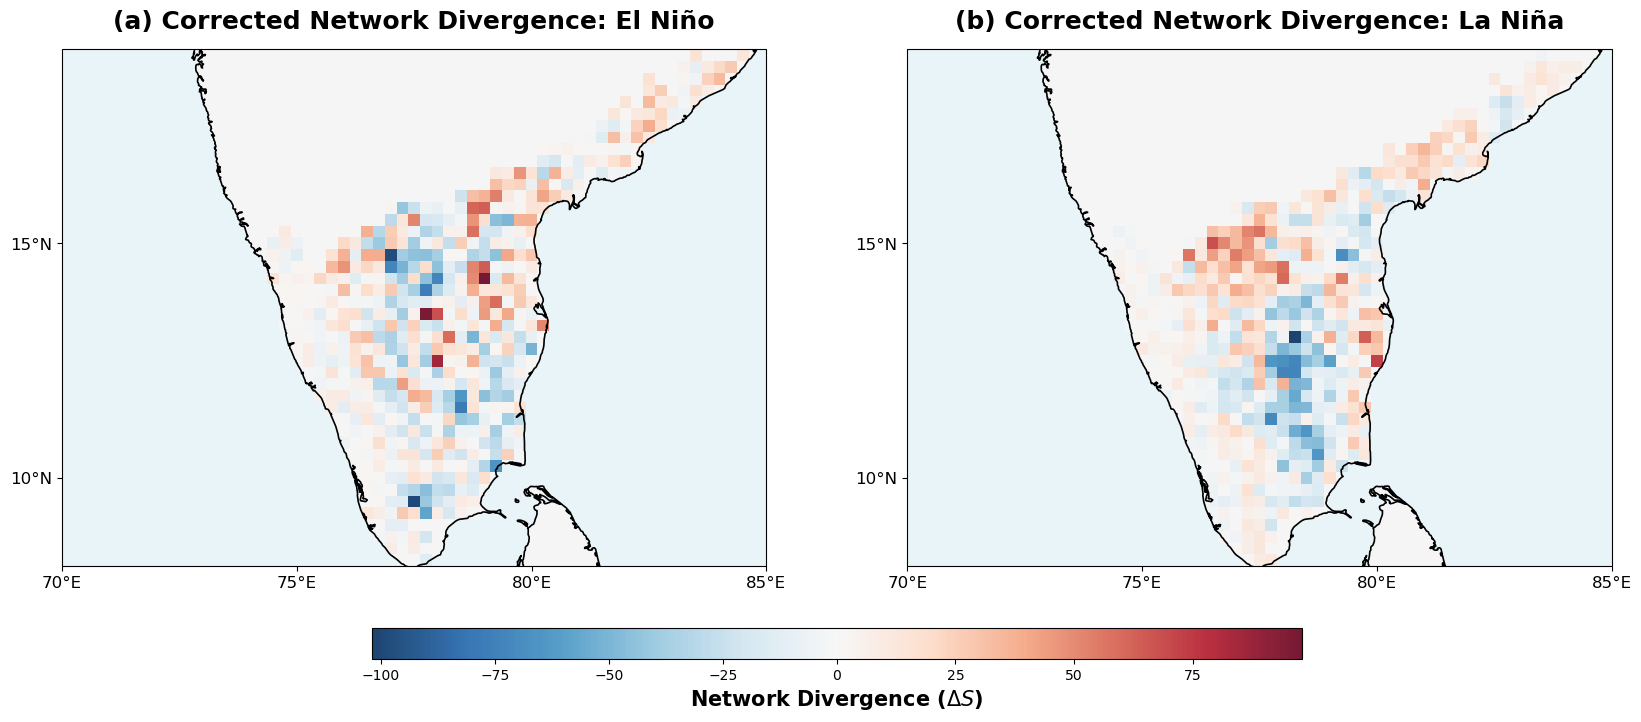

In [60]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.colors as mcolors

# =====================================================================
# 5. 수정된 데이터 기반 서브플롯(Subplot) 지도 시각화 
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# 공통 스케일 맞추기 (0을 중앙에 맞추어 Source는 붉은색, Sink는 푸른색으로 고정)
vmax = max(np.nanmax(div_elnino), np.nanmax(div_lanina))
vmin = min(np.nanmin(div_elnino), np.nanmin(div_lanina))

# 에러 방지용 (값이 모두 0이거나 한쪽 부호만 있을 경우)
if vmax <= 0: vmax = 1
if vmin >= 0: vmin = -1

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = plt.get_cmap('RdBu_r')

titles = ['(a) Corrected Network Divergence: El Niño', '(b) Corrected Network Divergence: La Niña']
div_data = [div_elnino, div_lanina]

for ax, data, title in zip(axes, div_data, titles):
    # 배경 설정 (바다와 육지 색상)
    ax.add_feature(cfeature.OCEAN, facecolor='#E8F4F8', zorder=0) 
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=1.2, edgecolor='black', zorder=3)

    # 1D 배열을 2D 격자로 변환 (lons, lats는 이전에 정의된 변수 사용)
    df_div = pd.DataFrame({'lon': lons, 'lat': lats, 'divergence': data})
    grid_div = df_div.pivot(index='lat', columns='lon', values='divergence')
    lon_mesh, lat_mesh = np.meshgrid(grid_div.columns, grid_div.index)
    
    # 색상 칠하기
    mesh = ax.pcolormesh(lon_mesh, lat_mesh, grid_div.values, 
                         cmap=cmap, norm=norm, shading='nearest', 
                         transform=ccrs.PlateCarree(), zorder=1, alpha=0.9)
    
    # 축 눈금 및 라벨 포맷팅
    ax.set_xticks(np.arange(70, 90, 5), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(10, 20, 5), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)

# 공통 컬러바 하단에 추가
cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal', pad=0.08, shrink=0.6, aspect=30)
cbar.set_label('Network Divergence ($\Delta S$)', fontsize=15, fontweight='bold')

plt.savefig('ENSO_Divergence_Comparison_Corrected.png', dpi=300, bbox_inches='tight')
print("🎉 시각화 맵핑 완료! 수정된 진짜 데이터가 반영된 'ENSO_Divergence_Comparison_Corrected.png'를 확인하세요.")

✅ 인접 행렬(Adjacency Matrix) 시각화 완료! 'Adjacency_Matrices_Comparison.png' 파일이 저장되었습니다.

📊 [네트워크 지표 수치 비교표]


,Original (전체 기간),La Niña (라니냐 기간),El Niño (엘니뇨 기간)
Total Edges (총 연결선 수),58890.00,47771.0,29818.00
Max Total Degree (가장 강력한 코어의 총 연결수),456.00,412.0,335.00
Average Degree (네트워크 평균 연결수),203.77,165.3,103.18
Max Divergence (가장 강력한 발원지 점수),73.00,72.0,98.00
Min Divergence (가장 강력한 종착지 점수),-101.00,-102.0,-99.00


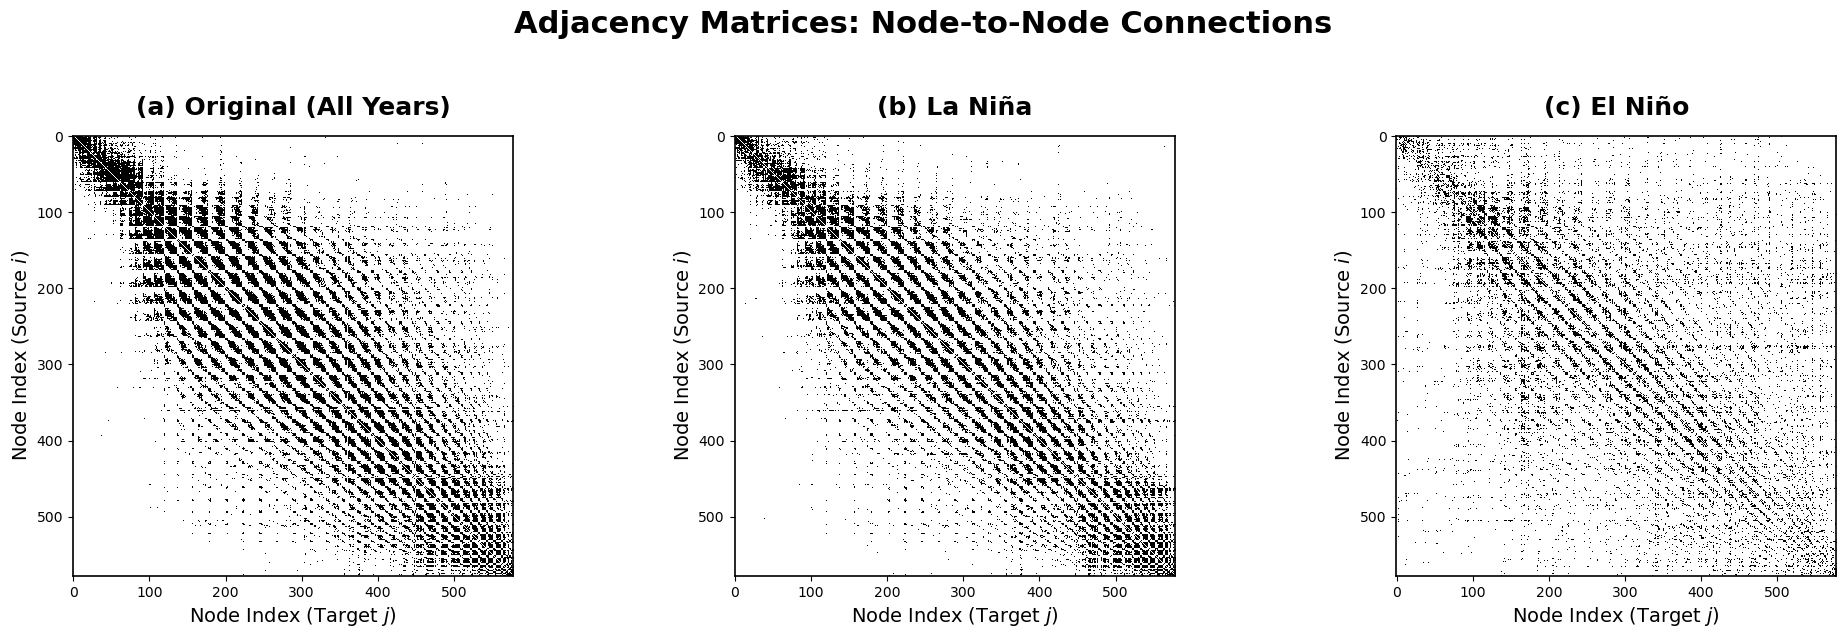

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. 원본 데이터의 Degree 및 Divergence 재계산 (변수명 통일)
# =====================================================================
# A_matrix는 이전 셀에서 실행하여 메모리에 남아있는 상태를 전제로 합니다.
k_out_orig = np.sum(A_matrix, axis=1).astype(int)
k_in_orig = np.sum(A_matrix, axis=0).astype(int)

div_orig = k_out_orig - k_in_orig
deg_orig = k_out_orig + k_in_orig

# =====================================================================
# 2. 정사각형 Node-to-Node 인접 행렬(Adjacency Matrix) 시각화
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

titles = ['(a) Original (All Years)', '(b) La Niña', '(c) El Niño']
matrices = [A_matrix, A_lanina, A_elnino]

for ax, matrix, title in zip(axes, matrices, titles):
    # 행렬을 흑백 이미지로 표현 (1=연결됨(검정), 0=연결안됨(하양))
    cmap = plt.cm.binary 
    cax = ax.imshow(matrix, cmap=cmap, interpolation='none', aspect='equal')
    
    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Node Index (Target $j$)', fontsize=14)
    ax.set_ylabel('Node Index (Source $i$)', fontsize=14)
    
    # 테두리 및 눈금 설정
    ax.tick_params(axis='both', which='major', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

plt.suptitle('Adjacency Matrices: Node-to-Node Connections', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('Adjacency_Matrices_Comparison.png', dpi=300, bbox_inches='tight')
print("✅ 인접 행렬(Adjacency Matrix) 시각화 완료! 'Adjacency_Matrices_Comparison.png' 파일이 저장되었습니다.\n")

# =====================================================================
# 3. 네트워크 지표(Network Metrics) 정량적 수치 비교
# =====================================================================
def calculate_metrics(A, div, deg):
    return {
        "Total Edges (총 연결선 수)": int(np.sum(A)),
        "Max Total Degree (가장 강력한 코어의 총 연결수)": int(np.max(deg)),
        "Average Degree (네트워크 평균 연결수)": round(np.mean(deg), 2),
        "Max Divergence (가장 강력한 발원지 점수)": int(np.max(div)),
        "Min Divergence (가장 강력한 종착지 점수)": int(np.min(div))
    }

# 각 케이스별 지표 산출
metrics_orig = calculate_metrics(A_matrix, div_orig, deg_orig)
metrics_lanina = calculate_metrics(A_lanina, div_lanina, deg_lanina)
metrics_elnino = calculate_metrics(A_elnino, div_elnino, deg_elnino)

# 데이터프레임으로 통합
df_comparison = pd.DataFrame({
    'Original (전체 기간)': metrics_orig,
    'La Niña (라니냐 기간)': metrics_lanina,
    'El Niño (엘니뇨 기간)': metrics_elnino
})

print("📊 [네트워크 지표 수치 비교표]")
display(df_comparison) # 주피터 노트북 환경에 맞게 표 형태로 출력